# Data Exploration

In [2]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from textblob import TextBlob
import test_suite

In [3]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [4]:
# Load DF
df = pd.read_csv("data/training_data_clean.csv")

features = [
    "student_id",
    "model_use_cases",
    "academic_use_likelihood",
    "optimal_task_types",
    "suboptimal_freq",
    "suboptimal_task_types",
    "suboptimal_example",
    "reference_expectation",
    "response_verification_freq",
    "verification_method",
    "label"
]

df.columns = features

# Converting Categorical to Ints
onehot_vecs = ["academic_use_likelihood", "suboptimal_freq", "reference_expectation", "response_verification_freq"]

for i in onehot_vecs:
    df[i] = df[i].str[0].astype('Int64')

# Converting Categorical to One Hots as well
for i in onehot_vecs:
    for j in range(2, 6):
        df[f"onehot_{j}_{i}"] = df[i] == j


categories = {
    "math": "Math computations",
    "data_processing": "Data processing or analysis",
    "explain": "Explaining complex concepts simply",
    "essay": "Writing or editing essays/reports",
    "professional": "Drafting professional text",
    "code": "Writing or debugging code",
    "format": "Converting content between formats",
    "idea": "Brainstorming or generating creative ideas"
}

for i, j in categories.items():
    df["optimal_" + i] = df["optimal_task_types"].str.contains(j)
df.drop("optimal_task_types", axis=1)

for i, j in categories.items():
    df["suboptimal_" + i] = df["suboptimal_task_types"].str.contains(j)
df.drop("suboptimal_task_types", axis=1)

df['sum_optimals'] = df[["optimal_" + i for i in categories]].sum(axis=1)
df['sum_suboptimals'] = df[["suboptimal_" + i for i in categories]].sum(axis=1)

# Sentiment Analysis
def analyze_sentiment(df_, col_):
    temp = df[col_].astype(str).apply(TextBlob)
    df_[f"{col_}_polarity"] = temp.apply(lambda x: x.sentiment.polarity)
    df_[f"{col_}_subjectivity"] = temp.apply(lambda x: x.sentiment.subjectivity)

    return df_

sentiment_cols = ["model_use_cases", "suboptimal_example", "verification_method"]
for col in sentiment_cols:
    df = analyze_sentiment(df, col)

df.head()


,student_id,model_use_cases,academic_use_likelihood,optimal_task_types,suboptimal_freq,suboptimal_task_types,suboptimal_example,reference_expectation,response_verification_freq,verification_method,...,suboptimal_format,suboptimal_idea,sum_optimals,sum_suboptimals,model_use_cases_polarity,model_use_cases_subjectivity,suboptimal_example_polarity,suboptimal_example_subjectivity,verification_method_polarity,verification_method_subjectivity
0,1,"General purpose tasks, like translating text, ...",3,"Math computations,Data processing or analysis,...",3,"Writing or debugging code,Explaining complex c...",I find that [THIS MODEL] has too much watering...,1,4,I double check with google searches or find fo...,...,True,True,5,4,0.050,0.500000,-0.031111,0.456111,-0.25,0.150000
1,1,Coding,4,Writing or debugging code,3,"Math computations,Explaining complex concepts ...",Many times when i try to get [THIS MODEL] to d...,1,5,I make sure that the code it writes is well wr...,...,False,True,1,4,0.000,0.000000,0.040000,0.520000,0.50,0.888889
2,1,"Math, coding sometimes",3,"Math computations,Converting content between f...",4,"Data processing or analysis,Drafting professio...",[THIS MODEL] likes to put a lot of words and e...,2,3,I make sure the facts its giving is correct. s...,...,False,True,2,3,0.000,0.000000,0.100000,0.650000,0.25,0.506944
3,2,"General first case go-to, catch-all type of m...",5,"Explaining complex concepts simply,Converting ...",4,"Writing or debugging code,Data processing or a...","Gave it the main ideas I wanted included, but...",3,2,Ask model to verify and doublecheck itself mu...,...,False,False,5,4,0.075,0.421667,0.120833,0.316667,0.00,0.331250
4,2,Coding/debugging Problem-solving Coming up ...,4,"Math computations,Writing or debugging code,Da...",4,"Data processing or analysis,Explaining complex...",Explain a complex concept Just restated the ...,2,1,#NAME?,...,True,True,4,6,0.000,0.000000,-0.333333,0.500000,0.00,0.000000


In [5]:
# Train, Valid, Test Split
seed = 42
#
# np.random.seed(seed)
#
# sid = df["student_id"].unique()
# np.random.shuffle(sid)
#
# sid_train = sid[0: len(sid) * 3 // 5]
# sid_valid = sid[len(sid) * 3 // 5 : len(sid) * 4 // 5]
# sid_test = sid[len(sid) * 4 // 5:]
#
#
# df_train = pd.merge(pd.DataFrame({"student_id": sid_train}), df, on="student_id", how="inner").dropna()
# df_valid = pd.merge(pd.DataFrame({"student_id": sid_valid}), df, on="student_id", how="inner").dropna()
# df_test = pd.merge(pd.DataFrame({"student_id": sid_test}), df, on="student_id", how="inner").dropna()

df_train, df_valid, df_test = test_suite.split_dataset(df, seed=seed)

print(f"Train set: {len(df_train.student_id.unique())} sids, {len(df_train)} rows")
print(f"Validation set: {len(df_valid.student_id.unique())} sids, {len(df_valid)} rows")
print(f"Test set: {len(df_test.student_id.unique())} sids, {len(df_test)} rows")


Train set: 164 sids, 435 rows
Validation set: 55 sids, 151 rows
Test set: 55 sids, 148 rows


# Data Exploration

<Figure size 1400x600 with 0 Axes>

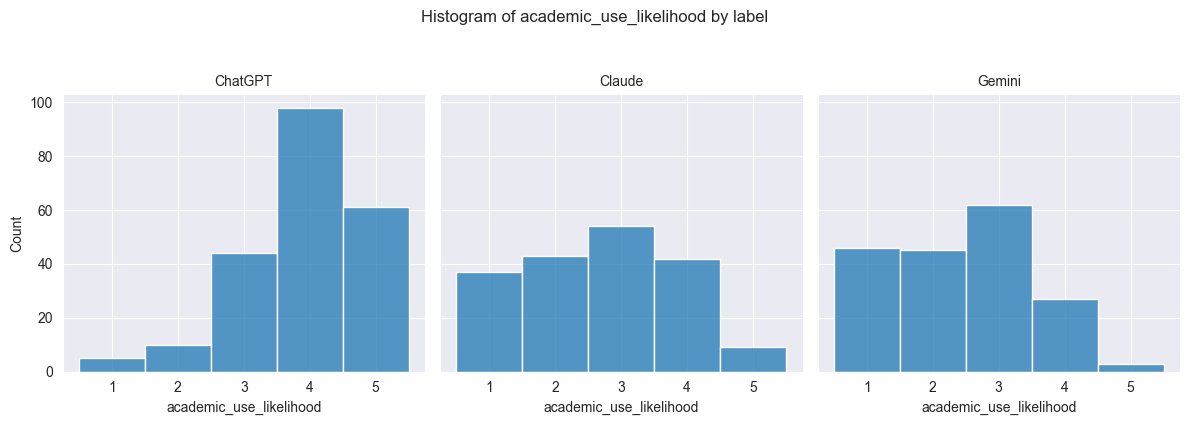

<Figure size 1400x600 with 0 Axes>

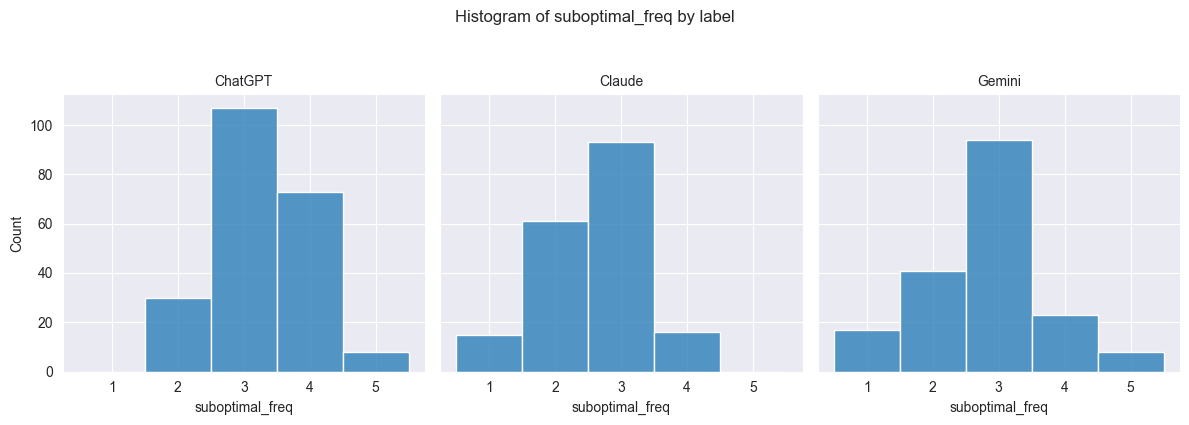

<Figure size 1400x600 with 0 Axes>

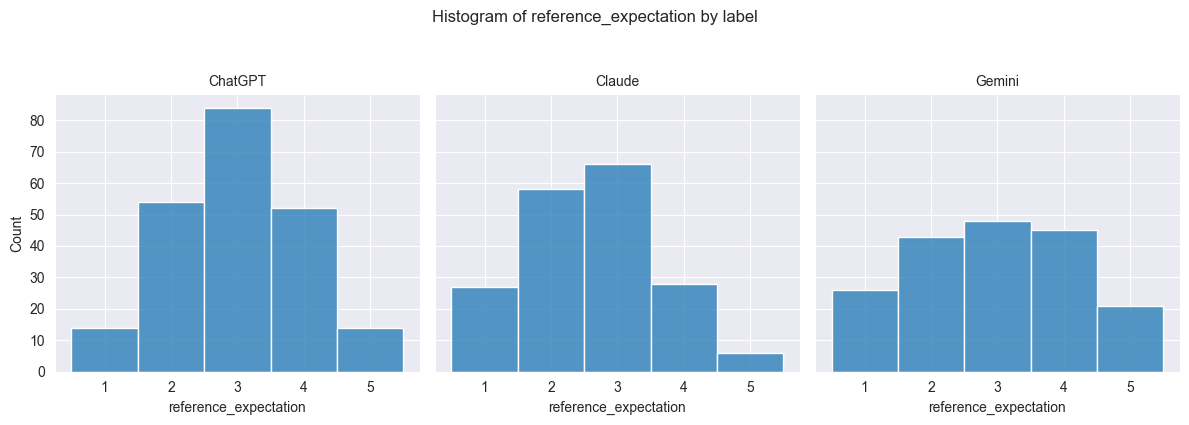

<Figure size 1400x600 with 0 Axes>

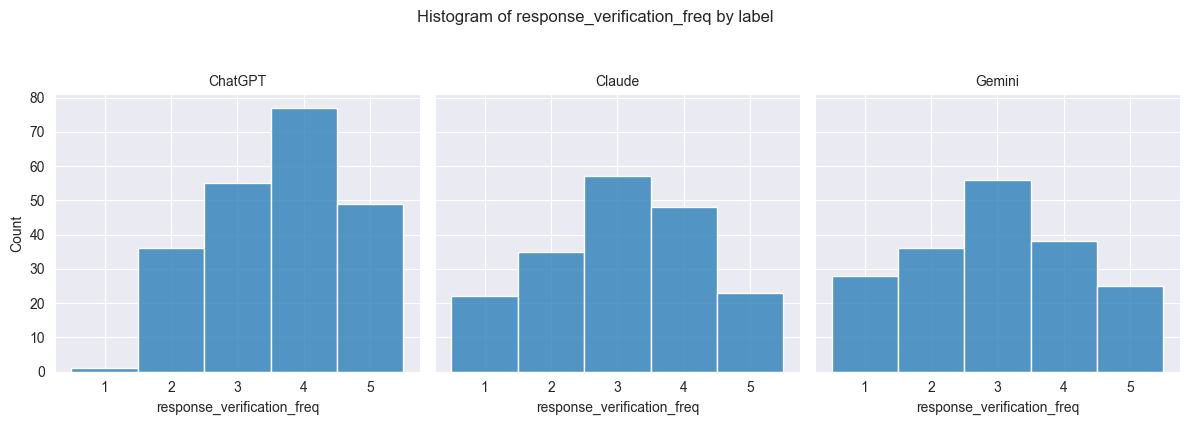

<Figure size 1400x600 with 0 Axes>

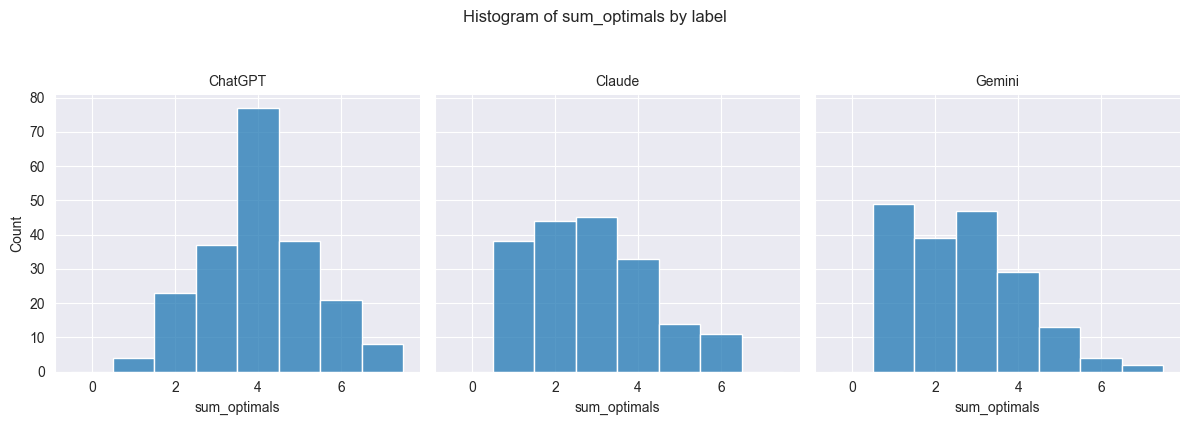

<Figure size 1400x600 with 0 Axes>

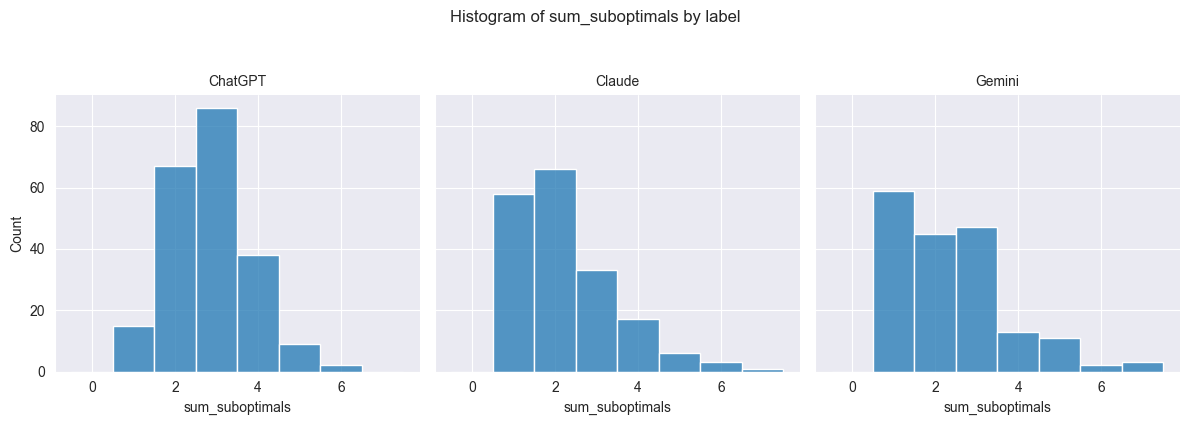

<Figure size 1400x600 with 0 Axes>

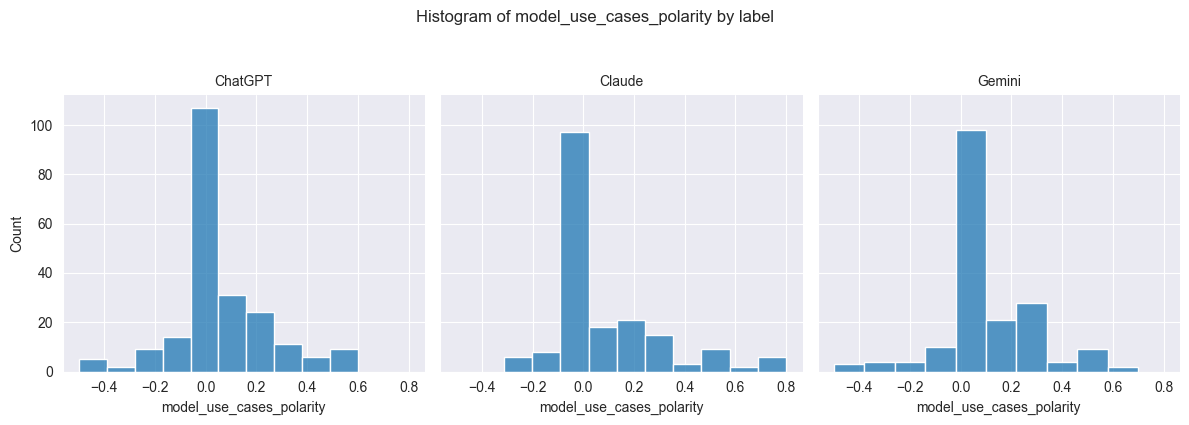

<Figure size 1400x600 with 0 Axes>

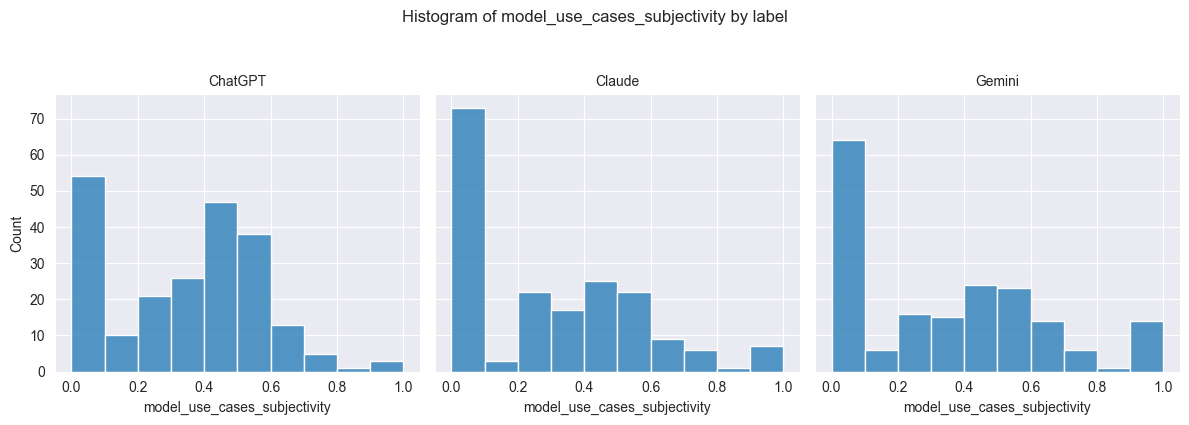

<Figure size 1400x600 with 0 Axes>

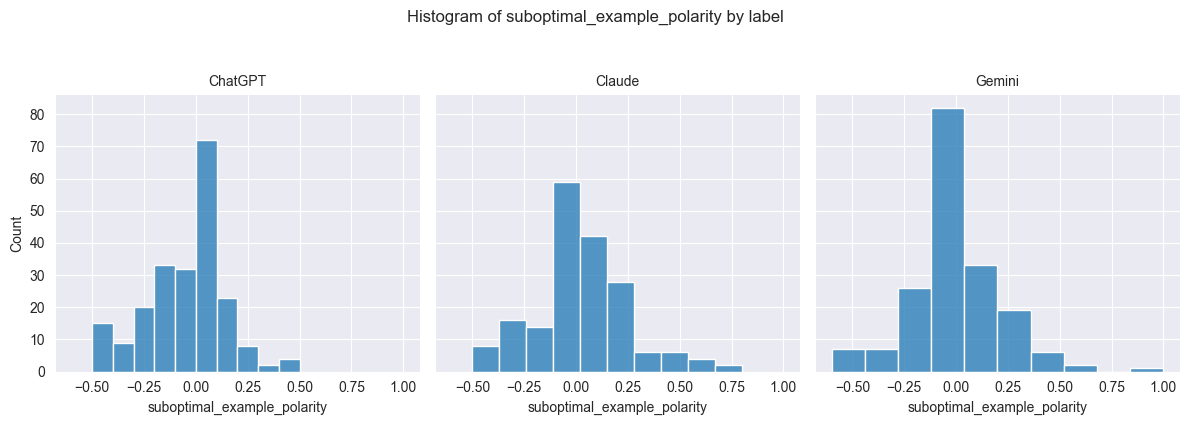

<Figure size 1400x600 with 0 Axes>

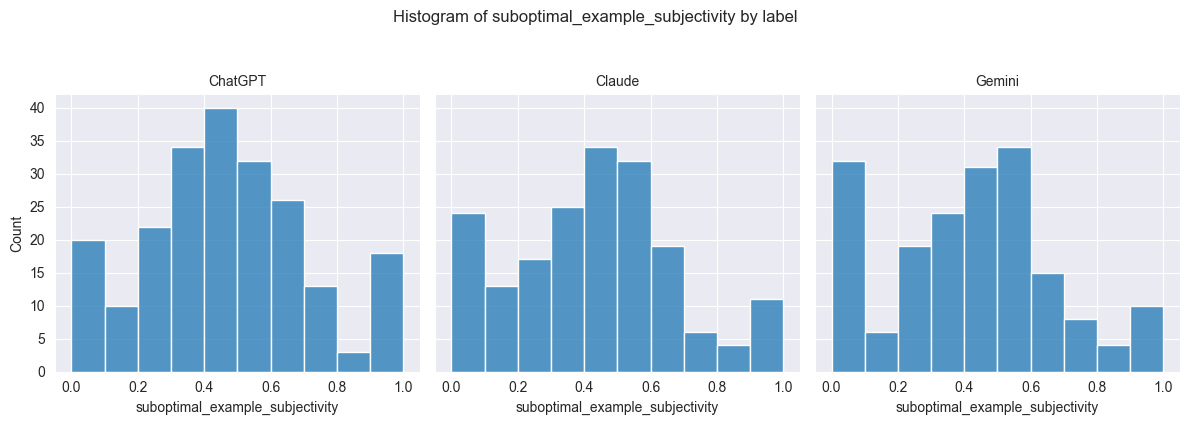

<Figure size 1400x600 with 0 Axes>

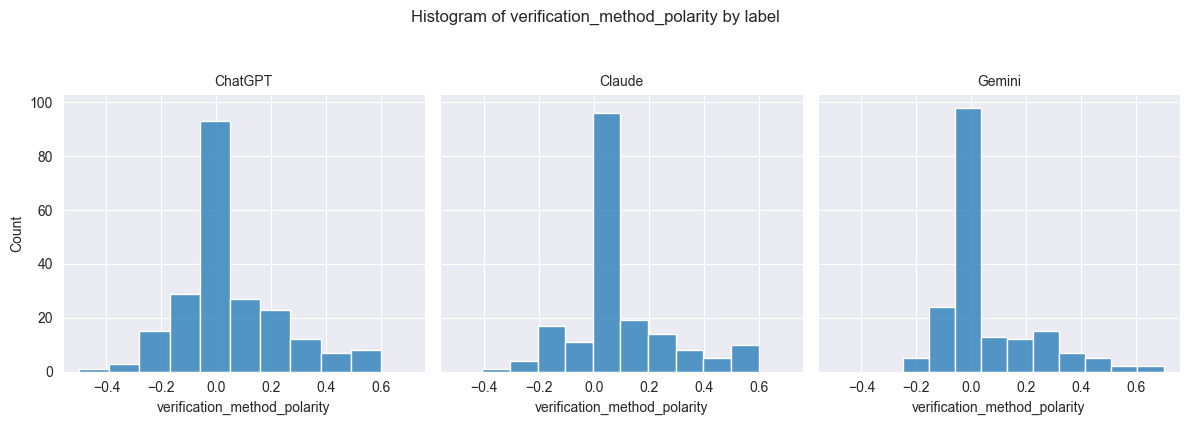

<Figure size 1400x600 with 0 Axes>

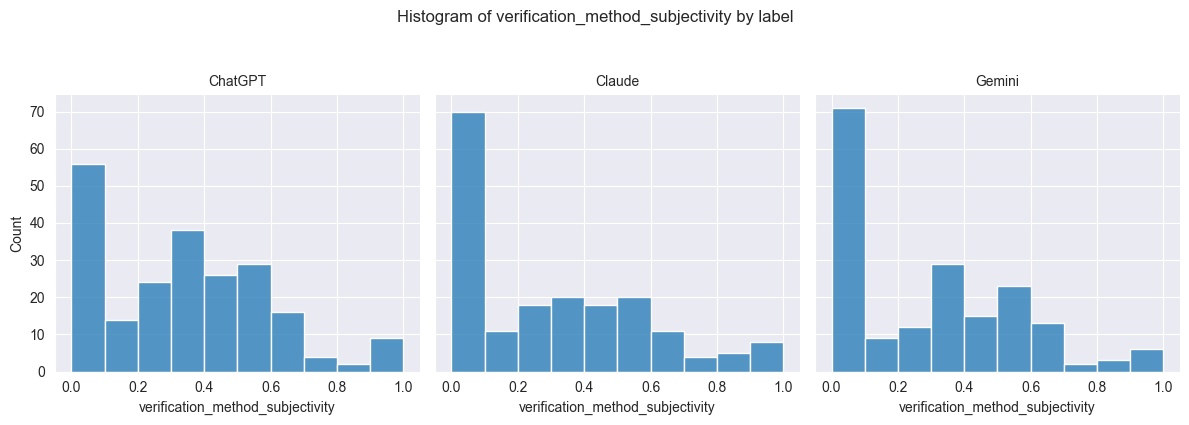

In [ ]:
# Histograms
plot_cols = ['academic_use_likelihood', 'suboptimal_freq', 'reference_expectation',
             'response_verification_freq']

for col in plot_cols:
    plt.figure(figsize=(14, 6))

    # Faceted histograms (separate plot for each label)
    g = sns.FacetGrid(pd.concat([df_train, df_valid]), col="label", sharex=True, sharey=True, height=4, aspect=1)
    g.map_dataframe(sns.histplot, x=col, bins=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5], kde=False)
    g.set_titles(col_template="{col_name}")
    g.fig.suptitle(f'Histogram of {col} by label', y=1.05)

    plt.tight_layout()
    plt.show()


plot_cols_2 = ['sum_optimals', 'sum_suboptimals']

for col in plot_cols_2:
    plt.figure(figsize=(14, 6))

    # Faceted histograms (separate plot for each label)
    g = sns.FacetGrid(pd.concat([df_train, df_valid]), col="label", sharex=True, sharey=True, height=4, aspect=1)
    g.map_dataframe(sns.histplot, x=col, bins=[-0.5 + i for i in range(len(categories) + 1)], kde=False)
    g.set_titles(col_template="{col_name}")
    g.fig.suptitle(f'Histogram of {col} by label', y=1.05)

    plt.tight_layout()
    plt.show()

plot_cols_3 = [f"{i}_{j}" for i in sentiment_cols for j in ["polarity", "subjectivity"]]
for col in plot_cols_3:
    plt.figure(figsize=(14, 6))

    # Faceted histograms (separate plot for each label)
    g = sns.FacetGrid(pd.concat([df_train, df_valid]), col="label", sharex=True, sharey=True, height=4, aspect=1)
    g.map_dataframe(sns.histplot, x=col, bins=10, kde=False)
    g.set_titles(col_template="{col_name}")
    g.fig.suptitle(f'Histogram of {col} by label', y=1.05)

    plt.tight_layout()
    plt.show()

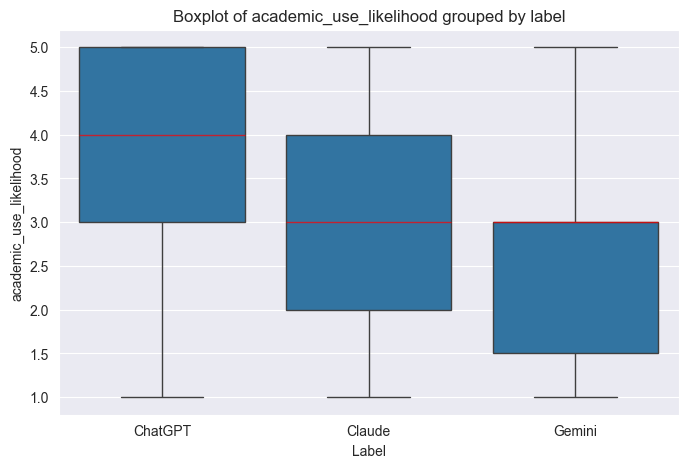

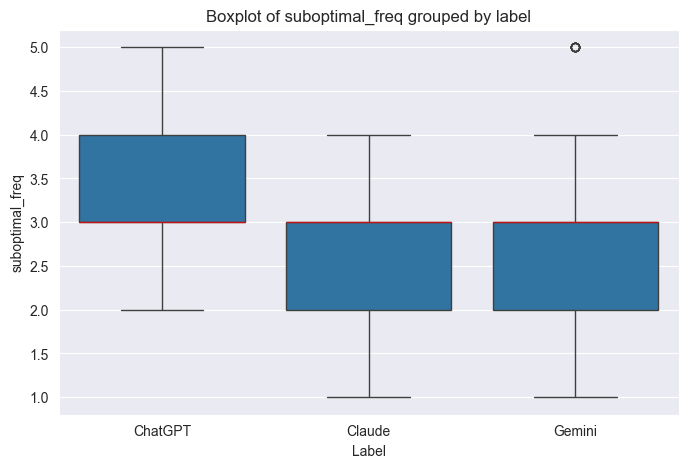

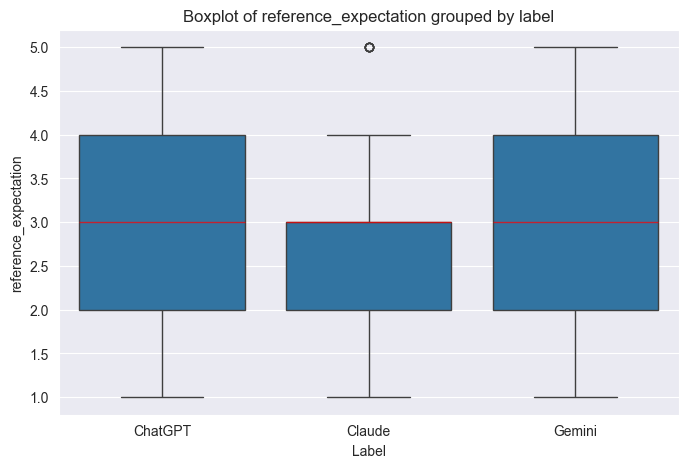

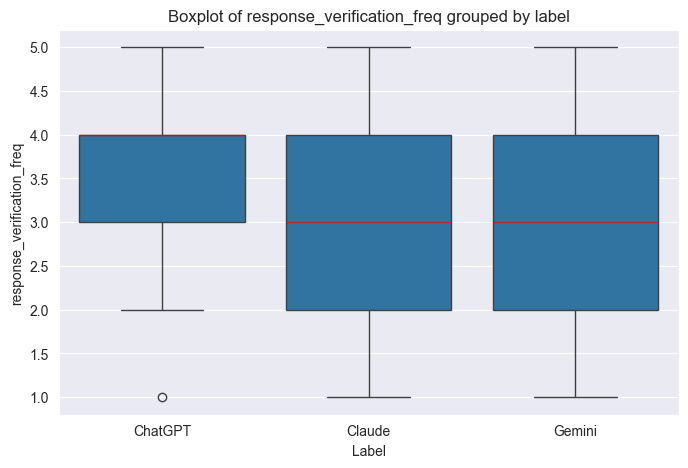

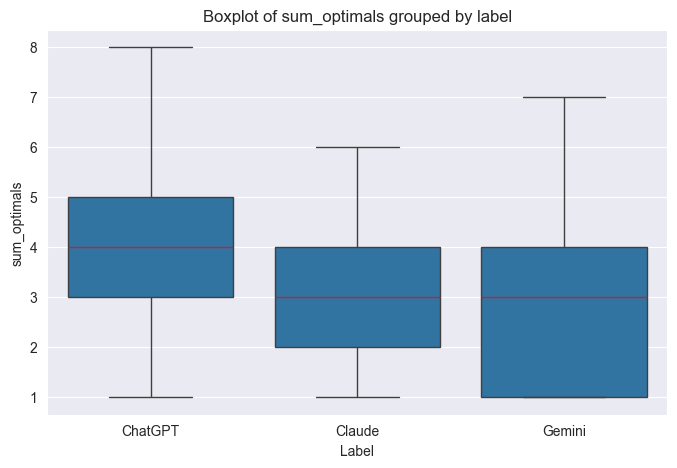

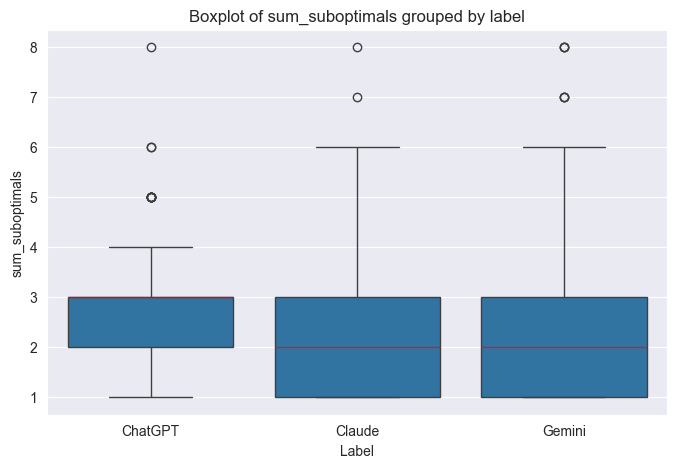

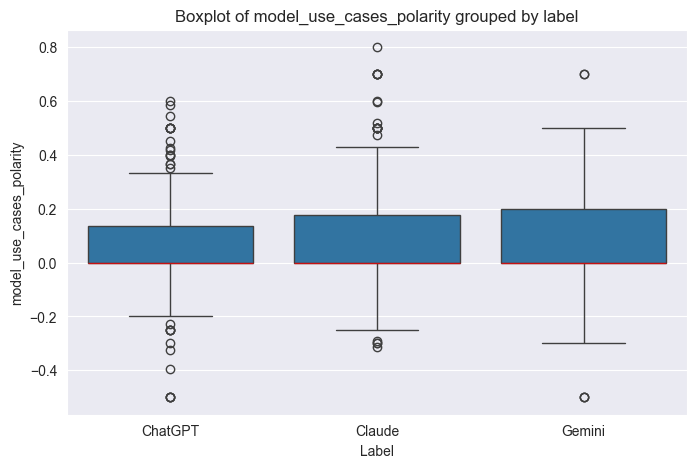

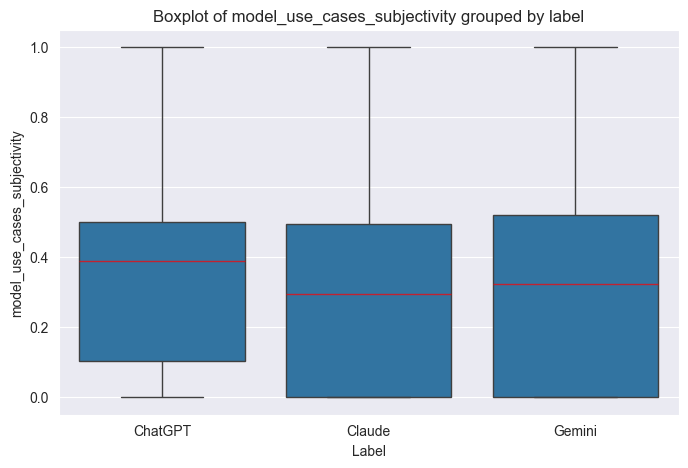

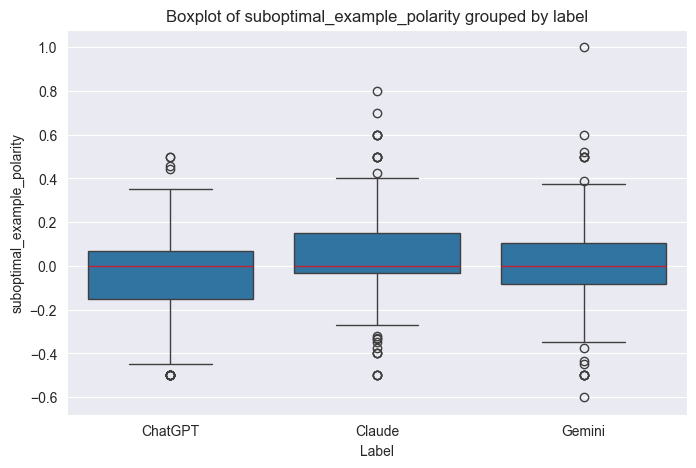

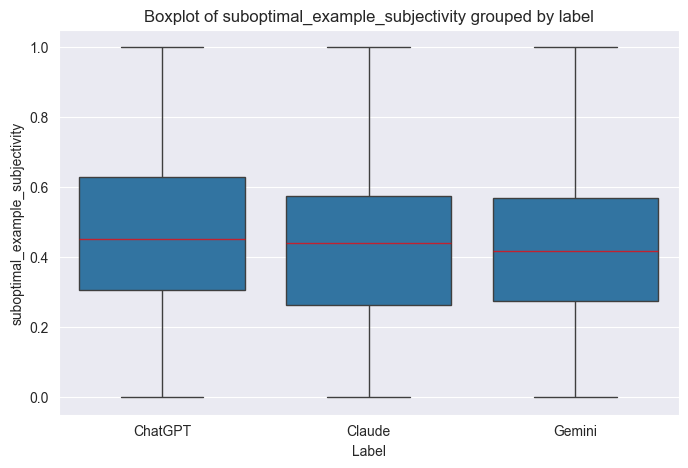

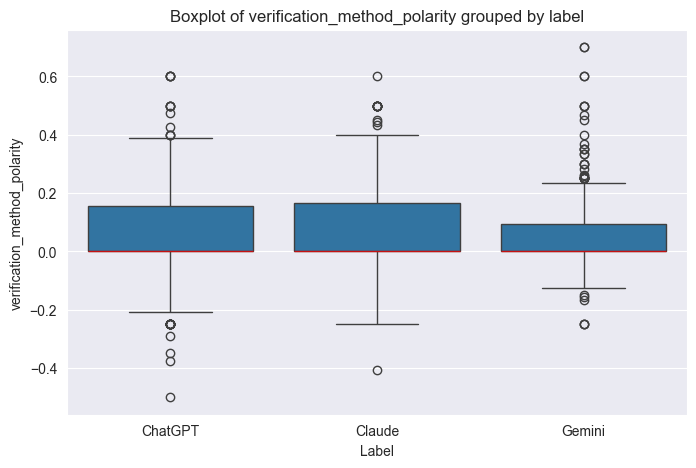

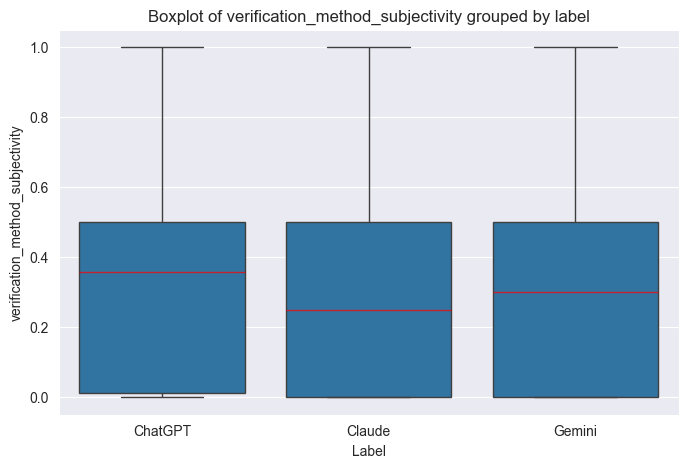

In [ ]:
# Boxplots
for col in (plot_cols + plot_cols_2 + plot_cols_3):
    plt.figure(figsize=(8, 5))
    ax = sns.boxplot(x='label', y=col, data=pd.concat([df_train, df_valid]), medianprops=dict(color="red", alpha=0.7))
    plt.title(f'Boxplot of {col} grouped by label')
    plt.xlabel('Label')
    plt.ylabel(col)
    plt.show()



# Prelim Model Fitting

In [6]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

In [7]:
# Basic Features
lr_feats = onehot_vecs + ["optimal_" + i for i in categories] + ["suboptimal_" + i for i in categories] + [f"{i}_{j}" for i in sentiment_cols for j in ["polarity", "subjectivity"]]
lr_feats_oh = [f"onehot_{j}_{i}" for i in onehot_vecs for j in range(2, 6)] + ["optimal_" + i for i in categories] + ["suboptimal_" + i for i in categories] + [f"{i}_{j}" for i in sentiment_cols for j in ["polarity", "subjectivity"]]
lr_label = 'label'

X_train = df_train[lr_feats]
X_train_oh = df_train[lr_feats_oh]
y_train = df_train[lr_label]

X_valid = df_valid[lr_feats]
X_valid_oh = df_valid[lr_feats_oh]
y_valid = df_valid[lr_label]

X_test = df_test[lr_feats]
X_test_oh = df_test[lr_feats_oh]
y_test = df_test[lr_label]

In [16]:
test_suite.train_model_sklearn(LogisticRegression(random_state=seed), X_train, y_train, X_valid, y_valid)
test_suite.train_model_sklearn(DecisionTreeClassifier(random_state=seed), X_train, y_train, X_valid, y_valid)
test_suite.train_model_sklearn(DecisionTreeClassifier(random_state=seed, criterion="entropy"), X_train, y_train, X_valid, y_valid)
test_suite.train_model_sklearn(RandomForestClassifier(random_state=seed), X_train, y_train, X_valid, y_valid)
test_suite.train_model_sklearn(SVC(random_state=seed), X_train, y_train, X_valid, y_valid)
test_suite.train_model_sklearn(GaussianNB(), X_train, y_train, X_valid, y_valid)


LogisticRegression Validation Accuracy: 0.7285
DecisionTreeClassifier Validation Accuracy: 0.5828
DecisionTreeClassifier Validation Accuracy: 0.5762
RandomForestClassifier Validation Accuracy: 0.7020
SVC Validation Accuracy: 0.7285
GaussianNB Validation Accuracy: 0.6755


In [17]:
# Gridsearch
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(random_state=seed, max_iter=200)
param_grid = {
    'penalty': ['l2', None],
    'C': [0.001, 0.01, 0.05, 0.075, 0.1, 0.25, 0.5, 1, 2, 5, 10, 25, 50, 100]
}

grid_search = GridSearchCV(estimator=log_reg, param_grid=param_grid, cv=5, verbose=1)

grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_}")

valid_score = grid_search.score(X_valid, y_valid)
print(f"Test set score: {valid_score}")


Fitting 5 folds for each of 28 candidates, totalling 140 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning: Setting penalty=None will ignore the C and

Best parameters: {'C': 0.05, 'penalty': 'l2'}
Best cross-validation score: 0.664367816091954
Test set score: 0.7218543046357616
